In [22]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from utils import update_predictions, compute_robustness_scores
from matplotlib import pyplot as plt
import seaborn as sns

In [10]:
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))
X_test = newsgroups_test.data
y_test = newsgroups_test.target
target_names = newsgroups_test.target_names

idx = 2
base_text = X_test[idx]
true_label = target_names[y_test[idx]]

print(f"Selected sample index: {idx}")
print(f"True label: {true_label}")
print("Base text:\n", base_text)

Selected sample index: 2
True label: alt.atheism
Base text:
 
In a word, yes.



In [11]:
df = pd.read_csv("2variants.csv")

df.head()

,base_text_id,text,model_prediction,model_confidence,llm_prediction,llm_confidence
0,2,"In brief, yes.\n\n2. The answer is yes.",NaN,NaN,NaN,NaN
1,2,"Yes, to put it simply.\n\n3. Absolutely, yes.",NaN,NaN,NaN,NaN
2,2,"A resounding yes.\n\n4. Yes, in short.",NaN,NaN,NaN,NaN
3,2,"Briefly put, yes.\n\n5. Yes, no need for elabo...",NaN,NaN,NaN,NaN
4,2,"Simply put, yes.",NaN,NaN,NaN,NaN


In [12]:
index = df["base_text_id"]
df["True Label"] = target_names[y_test[idx]]

df.head()

,base_text_id,text,model_prediction,model_confidence,llm_prediction,llm_confidence,True Label
0,2,"In brief, yes.\n\n2. The answer is yes.",NaN,NaN,NaN,NaN,alt.atheism
1,2,"Yes, to put it simply.\n\n3. Absolutely, yes.",NaN,NaN,NaN,NaN,alt.atheism
2,2,"A resounding yes.\n\n4. Yes, in short.",NaN,NaN,NaN,NaN,alt.atheism
3,2,"Briefly put, yes.\n\n5. Yes, no need for elabo...",NaN,NaN,NaN,NaN,alt.atheism
4,2,"Simply put, yes.",NaN,NaN,NaN,NaN,alt.atheism


In [13]:
import joblib

pipeline = joblib.load("../02_Pipeline/saved_pipelines_20news/full_text/tfidf_svm.pkl")

df_updated = update_predictions(df, pipeline, target_names)

[Error parsing Ollama response for row 1]: could not convert string to float: '<confidence_score>'
[Error parsing Ollama response for row 99]: could not convert string to float: '<confidence_score>'


In [14]:
df_updated.head()

,base_text_id,text,model_prediction,model_confidence,llm_prediction,llm_confidence,True Label,lime_top_words
0,2,"In brief, yes.\n\n2. The answer is yes.",rec.motorcycles,0.181829,None,NaN,alt.atheism,"[yes, brief, answer, In, The, 2, is]"
1,2,"Yes, to put it simply.\n\n3. Absolutely, yes.",alt.atheism,0.148579,None,NaN,alt.atheism,"[Absolutely, Yes, yes, put, 3, it, to]"
2,2,"A resounding yes.\n\n4. Yes, in short.",comp.graphics,0.156322,rec.sport.baseball,0.4,alt.atheism,"[short, Yes, yes, 4, in, A, resounding]"
3,2,"Briefly put, yes.\n\n5. Yes, no need for elabo...",comp.graphics,0.236707,None,NaN,alt.atheism,"[need, Briefly, for, yes, Yes, elaboration, 5]"
4,2,"Simply put, yes.",alt.atheism,0.303511,misc.forsale,0.2,alt.atheism,"[yes, Simply, put]"


In [19]:
df_robustness = compute_robustness_scores(df_updated)
df_robustness.to_csv("robustness_scores.csv", index=False)
df_robustness.describe()

,base_text_id,model_prediction_variability,llm_prediction_variability,model_confidence_range,llm_confidence_range,lime_keyword_drift
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,55.321429,2.428571,2.464286,0.302786,0.257857,0.765071
std,29.172607,1.425393,0.881167,0.216251,0.283227,0.174870
min,2.000000,1.000000,1.000000,0.002000,0.000000,0.447000
25%,28.750000,1.000000,2.000000,0.143250,0.100000,0.604000
50%,52.500000,2.000000,2.000000,0.259500,0.150000,0.800500
75%,80.250000,3.250000,3.000000,0.430250,0.225000,0.911500
max,98.000000,5.000000,5.000000,0.806000,0.920000,1.000000


In [20]:
summary = {
    "Metric": ["Prediction Variability", "Confidence Range"],
    "Model Avg": [
        df_robustness["model_prediction_variability"].mean(),
        df_robustness["model_confidence_range"].mean()
    ],
    "LLM Avg": [
        df_robustness["llm_prediction_variability"].mean(),
        df_robustness["llm_confidence_range"].mean()
    ]
}

df_summary = pd.DataFrame(summary)
print(df_summary.round(3))

                   Metric  Model Avg  LLM Avg
0  Prediction Variability      2.429    2.464
1        Confidence Range      0.303    0.258


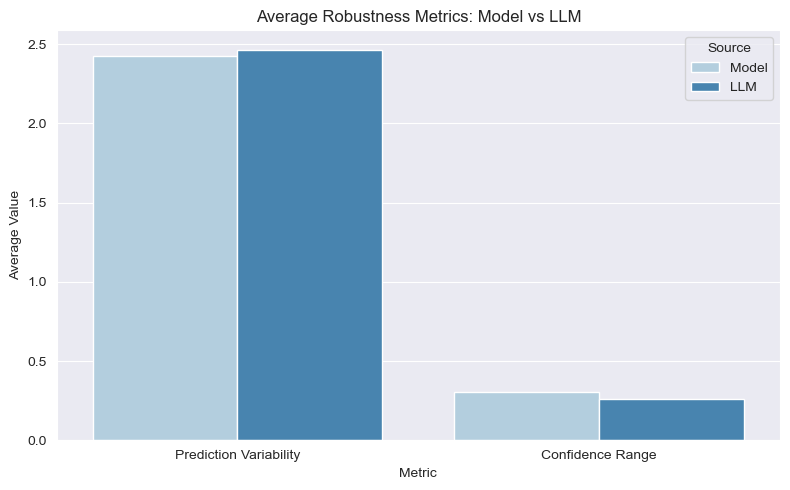

In [27]:
avg_model = [
    df_robustness["model_prediction_variability"].mean(),
    df_robustness["model_confidence_range"].mean()
]
avg_llm = [
    df_robustness["llm_prediction_variability"].mean(),
    df_robustness["llm_confidence_range"].mean()
]

df_plot = pd.DataFrame({
    "Metric": ["Prediction Variability", "Confidence Range"] * 2,
    "Value": avg_model + avg_llm,
    "Source": ["Model"] * 2 + ["LLM"] * 2
})

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x="Metric", y="Value", hue="Source", palette="Blues")
plt.title("Average Robustness Metrics: Model vs LLM")
plt.ylabel("Average Value")
plt.tight_layout()
plt.savefig("robustness.png", dpi=300)
plt.show()

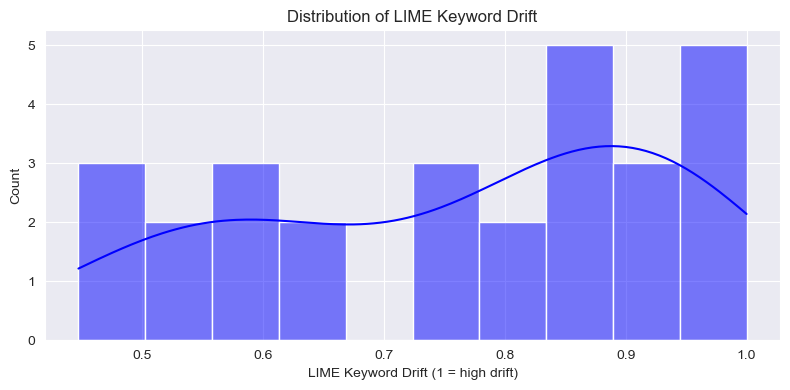

In [26]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(df_robustness["lime_keyword_drift"], bins=10, kde=True, color="blue")
plt.title("Distribution of LIME Keyword Drift")
plt.xlabel("LIME Keyword Drift (1 = high drift)")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig("LIME.png", dpi=300)
plt.show()